[SUCCESS] Loaded Dataset: 1014 records[cite: 1].
🔬 STARTING 5-FOLD RESEARCH MATRIX (This may take a minute)...
   -> Processing Fold 1/5...
   -> Processing Fold 2/5...
   -> Processing Fold 3/5...
   -> Processing Fold 4/5...
   -> Processing Fold 5/5...
✅ EVALUATION COMPLETE. GENERATING STATISTICAL PLOTS...


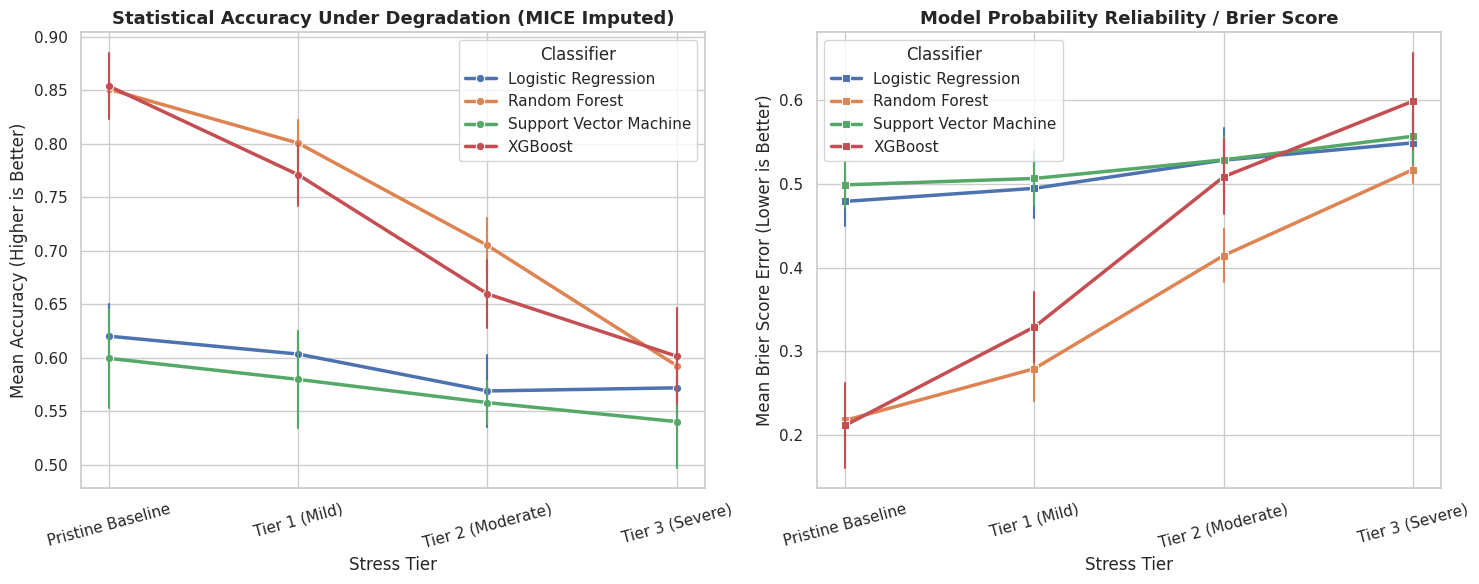

Acc_Mean  Acc_Std  Brier_Mean  \
Classifier             Tier                                               
Logistic Regression    Pristine Baseline    0.6203   0.0297      0.4792   
                       Tier 1 (Mild)        0.6036   0.0189      0.4948   
                       Tier 2 (Moderate)    0.5691   0.0334      0.5285   
                       Tier 3 (Severe)      0.5720   0.0253      0.5492   
Random Forest          Pristine Baseline    0.8511   0.0199      0.2172   
                       Tier 1 (Mild)        0.8008   0.0215      0.2791   
                       Tier 2 (Moderate)    0.7051   0.0257      0.4144   
                       Tier 3 (Severe)      0.5927   0.0161      0.5171   
Support Vector Machine Pristine Baseline    0.5996   0.0463      0.4989   
                       Tier 1 (Mild)        0.5799   0.0455      0.5066   
                       Tier 2 (Moderate)    0.5582   0.0200      0.5289   
                       Tier 3 (Severe)      0.5404   0.0430      0.5570   
XGBoost                Pristine Baseline    0.8541   0.0309      0.2113   
                       Tier 1 (Mild)        0.7712   0.0290      0.3290   
                       Tier 2 (Moderate)    0.6598   0.0320      0.5086   
                       Tier 3 (Severe)      0.6016   0.0447      0.5990   

                                          Brier_Std  
Classifier             Tier                          
Logistic Regression    Pristine Baseline     0.0300  
                       Tier 1 (Mild)         0.0351  
                       Tier 2 (Moderate)     0.0386  
                       Tier 3 (Severe)       0.0376  
Random Forest          Pristine Baseline     0.0378  
                       Tier 1 (Mild)         0.0383  
                       Tier 2 (Moderate)     0.0318  
                       Tier 3 (Severe)       0.0154  
Support Vector Machine Pristine Baseline     0.0280  
                       Tier 1 (Mild)         0.0329  
                       Tier 2 (Moderate)     0.0277  
                       Tier 3 (Severe)       0.0335  
XGBoost                Pristine Baseline     0.0505  
                       Tier 1 (Mild)         0.0417  
                       Tier 2 (Moderate)     0.0449  
                       Tier 3 (Severe)       0.0576

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn Modules for ML & Evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder

# Sklearn Modules for Advanced Imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Try importing XGBoost safely
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[WARNING] XGBoost not installed. It will be skipped.")

# Suppress harmless warnings for cleaner output
warnings.filterwarnings('ignore')

# =====================================================================
# 1. THE DATA DEGRADATION ENGINE[cite: 1]
# =====================================================================
class DataDegradationEngine:
    def __init__(self, random_state=42):
        self.rs = np.random.RandomState(random_state)

    def apply_mcar(self, df, missing_rate=0.05):
        """Stream A: Missing Completely At Random (MCAR) uniformly across features[cite: 1]."""
        corrupted_df = df.copy()
        mask = self.rs.rand(*corrupted_df.shape) < missing_rate
        corrupted_df[mask] = np.nan
        return corrupted_df

    def apply_mnar_stockout(self, df, target_col='BS', missing_rate=0.30):
        """Stream A: Missing Not At Random (MNAR) simulating a localized equipment stock-out[cite: 1]."""
        corrupted_df = df.copy()
        if target_col in corrupted_df.columns:
            mask = self.rs.rand(len(corrupted_df)) < missing_rate
            corrupted_df.loc[mask, target_col] = np.nan
        return corrupted_df

    def inject_gaussian_bp_noise(self, df, target_cols=['SystolicBP', 'DiastolicBP'], max_drift=15.0):
        """Stream B: Gaussian Noise for sensor drift (e.g., +/- 15 mmHg)[cite: 1]."""
        corrupted_df = df.copy()
        sigma = max_drift / 1.96 # 95% confidence interval scaling[cite: 1]
        for col in target_cols:
            if col in corrupted_df.columns:
                noise = self.rs.normal(0, sigma, size=len(corrupted_df))
                corrupted_df[col] = corrupted_df[col] + noise
        return corrupted_df

    def inject_biased_temp_noise(self, df, target_col='BodyTemp', bias_range=(-1.5, -0.5)):
        """Stream B: Uniform biased noise for calibration errors (e.g., underreporting)[cite: 1]."""
        corrupted_df = df.copy()
        if target_col in corrupted_df.columns:
            noise = self.rs.uniform(bias_range[0], bias_range[1], size=len(corrupted_df))
            corrupted_df[target_col] = corrupted_df[target_col] + noise
        return corrupted_df

# =====================================================================
# 2. DATA LOADING & PREPARATION
# =====================================================================
filename = "Maternal Health Risk Data Set.csv"
try:
    df = pd.read_csv(filename)
    print(f"[SUCCESS] Loaded Dataset: {df.shape[0]} records[cite: 1].")
except FileNotFoundError:
    raise FileNotFoundError(f"[ERROR] Could not find '{filename}'. Please upload it to Colab.")

# Isolate features and target
X = df.drop(columns=['RiskLevel']).values
y_raw = df['RiskLevel'].values
feature_names = df.drop(columns=['RiskLevel']).columns

# Encode labels to integers (0, 1, 2) required for XGBoost and Brier calculations
le = LabelEncoder()
y = le.fit_transform(y_raw)
lb = LabelBinarizer()
lb.fit(y)

# =====================================================================
# 3. CLINICAL SEVERITY TIERS[cite: 1]
# =====================================================================
tiers = {
    "Pristine Baseline": {"missing_rate": 0.00, "bp_drift": 0.0,  "temp_bias": (0.0, 0.0)},
    "Tier 1 (Mild)":      {"missing_rate": 0.05, "bp_drift": 5.0,  "temp_bias": (-0.5, -0.1)}, #[cite: 1]
    "Tier 2 (Moderate)":  {"missing_rate": 0.15, "bp_drift": 10.0, "temp_bias": (-1.0, -0.3)}, #[cite: 1]
    "Tier 3 (Severe)":    {"missing_rate": 0.30, "bp_drift": 15.0, "temp_bias": (-1.5, -0.5)}  #[cite: 1]
}

# =====================================================================
# 4. CROSS-VALIDATION MATRIX LOOP
# =====================================================================
engine = DataDegradationEngine(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("🔬 STARTING 5-FOLD RESEARCH MATRIX (This may take a minute)...")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"   -> Processing Fold {fold + 1}/5...")

    # Strict isolation: Data Splitting[cite: 1]
    X_train, X_test_fold = X[train_idx], X[test_idx]
    y_train, y_test_fold = y[train_idx], y[test_idx]

    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_fold, columns=feature_names)

    # Initialize Baseline Models[cite: 1]
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Support Vector Machine": SVC(probability=True, random_state=42)
    }
    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)

    # Fit Models on PRISTINE Training Data
    for name, model in models.items():
        model.fit(X_train_df, y_train)

    # Fit MICE Imputer strictly on Training Data to prevent leakage
    mice_imputer = IterativeImputer(random_state=42, max_iter=10)
    mice_imputer.fit(X_train_df)

    # Evaluate across all Severity Tiers
    for tier_name, configs in tiers.items():
        X_test_corrupted = X_test_df.copy()

        # Apply Degradation Engine
        if configs["missing_rate"] > 0:
            X_test_corrupted = engine.apply_mcar(X_test_corrupted, missing_rate=configs["missing_rate"])
            X_test_corrupted = engine.apply_mnar_stockout(X_test_corrupted, target_col='BS', missing_rate=configs["missing_rate"])
        if configs["bp_drift"] > 0:
            X_test_corrupted = engine.inject_gaussian_bp_noise(X_test_corrupted, max_drift=configs["bp_drift"])
        if configs["temp_bias"] != (0.0, 0.0):
            X_test_corrupted = engine.inject_biased_temp_noise(X_test_corrupted, bias_range=configs["temp_bias"])

        # Apply MICE Imputation defense
        X_test_defended = pd.DataFrame(mice_imputer.transform(X_test_corrupted), columns=feature_names)

        # Format labels for multi-class Brier calculation
        y_test_fold_bin = lb.transform(y_test_fold)

        # Generate predictions and track probabilities[cite: 1]
        for name, model in models.items():
            y_pred = model.predict(X_test_defended)
            y_prob = model.predict_proba(X_test_defended)

            acc = accuracy_score(y_test_fold, y_pred)
            brier = np.mean(np.sum((y_test_fold_bin - y_prob) ** 2, axis=1))

            cv_results.append({
                "Fold": fold + 1,
                "Tier": tier_name,
                "Classifier": name,
                "Accuracy": acc,
                "Brier Score": brier
            })

print("✅ EVALUATION COMPLETE. GENERATING STATISTICAL PLOTS...")

# =====================================================================
# 5. RESULTS FORMATTING & VISUALIZATION
# =====================================================================
cv_df = pd.DataFrame(cv_results)

# Configure Seaborn style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Plot 1: Mean Accuracy with standard deviation error bars
plt.subplot(1, 2, 1)
sns.lineplot(data=cv_df, x="Tier", y="Accuracy", hue="Classifier",
             marker="o", linewidth=2.5, err_style="bars", errorbar="sd")
plt.title("Statistical Accuracy Under Degradation (MICE Imputed)", fontsize=13, fontweight='bold')
plt.ylabel("Mean Accuracy (Higher is Better)")
plt.xlabel("Stress Tier")
plt.xticks(rotation=15)

# Plot 2: Mean Brier Score Error with standard deviation error bars
plt.subplot(1, 2, 2)
sns.lineplot(data=cv_df, x="Tier", y="Brier Score", hue="Classifier",
             marker="s", linewidth=2.5, err_style="bars", errorbar="sd")
plt.title("Model Probability Reliability / Brier Score", fontsize=13, fontweight='bold')
plt.ylabel("Mean Brier Score Error (Lower is Better)")
plt.xlabel("Stress Tier")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Display summary statistics table for the paper
summary_stats = cv_df.groupby(["Classifier", "Tier"])[["Accuracy", "Brier Score"]].agg(["mean", "std"])
summary_stats.columns = ['Acc_Mean', 'Acc_Std', 'Brier_Mean', 'Brier_Std']
display(summary_stats.round(4))

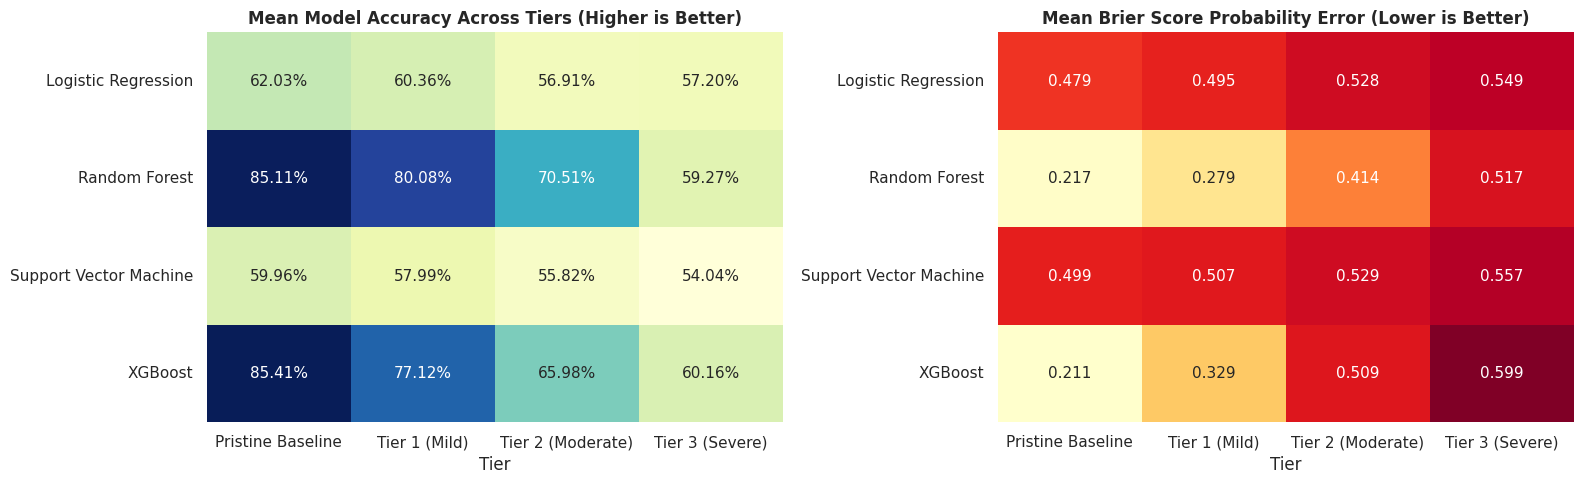

In [ ]:
# Format cross-validation summary table into a clean pivot matrix
pivot_acc = cv_df.groupby(["Classifier", "Tier"])["Accuracy"].mean().unstack()
pivot_brier = cv_df.groupby(["Classifier", "Tier"])["Brier Score"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap 1: Accuracy Matrix
sns.heatmap(pivot_acc, annot=True, fmt=".2%", cmap="YlGnBu", ax=axes[0], cbar=False, annot_kws={"size": 11})
axes[0].set_title("Mean Model Accuracy Across Tiers (Higher is Better)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("")

# Heatmap 2: Brier Score Matrix
sns.heatmap(pivot_brier, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1], cbar=False, annot_kws={"size": 11})
axes[1].set_title("Mean Brier Score Probability Error (Lower is Better)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

⏳ Computing SHAP values across all models...


  0%|          | 0/203 [00:00<?, ?it/s]

📊 Plotting SHAP Feature Importance across architectures...

1️⃣ Random Forest Feature Importance:


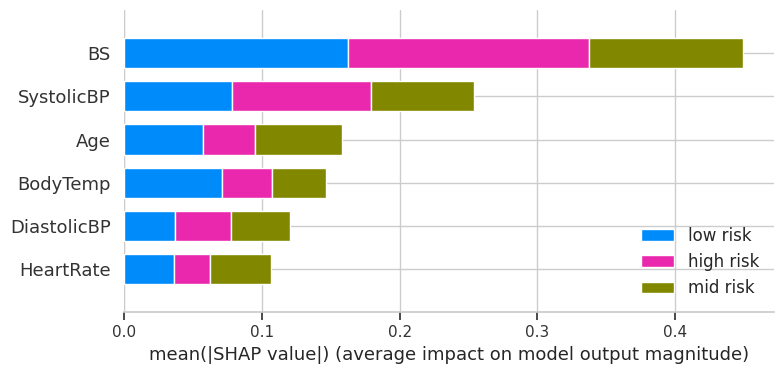

2️⃣ Logistic Regression Feature Importance:


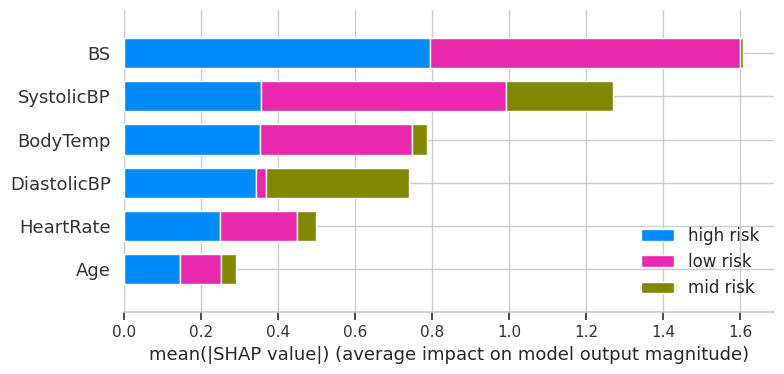

3️⃣ Support Vector Machine Feature Importance:


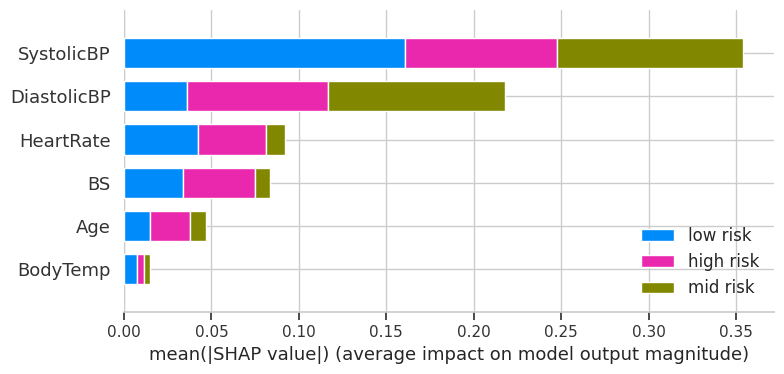

In [ ]:
!pip install -q shap
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Load Data
df = pd.read_csv("Maternal Health Risk Data Set.csv")
X = df.drop(columns=['RiskLevel'])
y = df['RiskLevel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Train Models
rf_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
svm_model = SVC(probability=True, random_state=42).fit(X_train, y_train)

# =====================================================================
# SHAP EVALUATION FOR ALL MODELS
# =====================================================================
print("⏳ Computing SHAP values across all models...")

# --- 1. Random Forest (TreeExplainer) ---
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_test)

# --- 2. Logistic Regression (LinearExplainer) ---
lr_explainer = shap.LinearExplainer(lr_model, X_train)
lr_shap_values = lr_explainer.shap_values(X_test)

# --- 3. Support Vector Machine (KernelExplainer with background sample for speed) ---
bg_summary = shap.kmeans(X_train, 10) # 10 background clusters to keep it fast
svm_explainer = shap.KernelExplainer(svm_model.predict_proba, bg_summary)
svm_shap_values = svm_explainer.shap_values(X_test)

# =====================================================================
# PLOTTING SHAP FOR EACH MODEL
# =====================================================================
print("📊 Plotting SHAP Feature Importance across architectures...\n")

# Plot 1: Random Forest
plt.figure()
print("1️⃣ Random Forest Feature Importance:")
shap.summary_plot(rf_shap_values, X_test, plot_type="bar", class_names=rf_model.classes_)

# Plot 2: Logistic Regression
plt.figure()
print("2️⃣ Logistic Regression Feature Importance:")
shap.summary_plot(lr_shap_values, X_test, plot_type="bar", class_names=lr_model.classes_)

# Plot 3: Support Vector Machine
plt.figure()
print("3️⃣ Support Vector Machine Feature Importance:")
shap.summary_plot(svm_shap_values, X_test, plot_type="bar", class_names=svm_model.classes_)